## Этап 1: парсинг

In [1]:
!pip3 install requests beautifulsoup4


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import time
import requests
import bs4

# response = requests.get('https://goldapple.ru/faq', verify=False)
# while response.status_code != 200:
#     time.sleep(1)
#     response = requests.get('https://goldapple.ru/faq')

# faq_html = response.text

with open('faq.html', 'r') as f:
    faq_html = f.read()
soup = bs4.BeautifulSoup(faq_html, 'html.parser')

In [3]:
soup

<!DOCTYPE html>

<!-- saved from url=(0024)https://goldapple.ru/faq -->
<html dir="ltr" lang="ru-RU" m_init="2259300202411131529" prefix="og: https://ogp.me/ns#" style="--window-inner-height: 869px;" translate="no">
<head>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=0" data-n-head="1" name="viewport"/>
<meta content="true" data-n-head="1" name="HandheldFriendly"/>
<meta content="width" data-n-head="1" name="MobileOptimized"/>
<meta content="yes" data-n-head="1" name="apple-mobile-web-app-capable"/>
<meta content="telephone=no, address=no, email=no" data-n-head="1" name="format-detection"/>
<meta content="only light" data-n-head="1" name="color-scheme"/>
<meta content="IE=edge" data-n-head="1" http-equiv="X-UA-Compatible"/>
<script async="" src="./FAQ — Вопросы и ответы в интернет-магазине _Золотое яблоко__files/tag.js"></script>
<script async="" src="./FAQ — Вопросы и ответы в ин

In [4]:
sections = soup.findAll('h2')  # ищем все разделы вопросов
sections

[<h2 class="main-block__heading heading-2 only-desktop">о заказе</h2>,
 <h2 class="main-block__heading heading-2 only-desktop">
                               отмена и возврат
                             </h2>,
 <h2 class="main-block__heading heading-2 only-desktop">доставка</h2>,
 <h2 class="main-block__heading heading-2 only-desktop">оплата</h2>,
 <h2 class="main-block__heading heading-2 only-desktop">
                               подарочные карты
                             </h2>,
 <h2 class="main-block__heading heading-2 only-desktop">
                               программа лояльности
                             </h2>,
 <h2 class="main-block__heading heading-2 only-desktop">
                               персональные данные
                             </h2>,
 <h2 class="main-block__heading heading-2 only-desktop">отзывы</h2>,
 <h2 class="main-block__heading heading-2 only-desktop">
                               как получать сообщения от Золотого Яблока
                   

In [5]:
for section in sections:
    questions = section.parent.findAll('h3')
    for question in questions:
        break
    break

In [6]:
question.parent.findChild('div').text

'\n\n\n                                      Добавьте нужные товары в корзину.\n                                    \n\nПерейдите к оформлению заказа.\n\n\n\n\n\nВыберите адрес и способ доставки.\n\n\n\n\n\nУкажите получателя.\n\n\n\n\n\nВыберите способ оплаты.\n\n\n\n\n\nОплатите заказ.\n\n\n\n\n\n'

In [8]:
import re

def nw(text):
    '''Normalization of whitespaces'''
    return re.sub(r'\s+', ' ', text).strip()

In [9]:
print(nw(question.parent.findChild('div').text))

Добавьте нужные товары в корзину. Перейдите к оформлению заказа. Выберите адрес и способ доставки. Укажите получателя. Выберите способ оплаты. Оплатите заказ.


In [10]:
documents = []

for i, section in enumerate(sections):
    questions = section.parent.findAll('h3')
    section = nw(section.text)
    for j, question in enumerate(questions):
        answer = nw(question.parent.findChild('div').text)
        question = nw(question.text)
        question = question if question[-1] == '?' else question + '?'
        documents.append({'id': f'{i}-{j}', 'text': f'## {section}: {question}\n\n{answer}', 'theme': section})
print(len(documents))
print(documents[42]['text'])

57
## подарочные карты: как узнать баланс карты?

пластиковая карта Отсканируйте QR-код на обратной стороне пластиковой карты — откроется новая страница, где будет доступен баланс и информация, как использовать карту. Если у вас есть мобильное приложение, ссылка откроется в нём, если нет — в браузере. Информация на новой странице доступна только по ссылке по QR-коду. электронная карта Номинал электронной карты доступен по ссылке из sms. При переходе откроется новая страница, где будет номинал и информация, как использовать карту. Баланс (текущий остаток) электронной карты доступен в личном кабинете в мобильном приложении или при оформлении заказа, когда вы добавите подарочную карты в способ оплаты.


In [11]:
import pandas as pd

documents = pd.DataFrame(documents)
documents.head(3)

,id,text,theme
0,0-0,## о заказе: как сделать заказ?\n\nДобавьте ну...,о заказе
1,0-1,## о заказе: не удалось оплатить заказ. Что де...,о заказе
2,0-2,## о заказе: почему заказ разделился на нескол...,о заказе


In [12]:
documents.to_excel('docs_qa_ga.xlsx')

## Этап 1.1: Визуализация

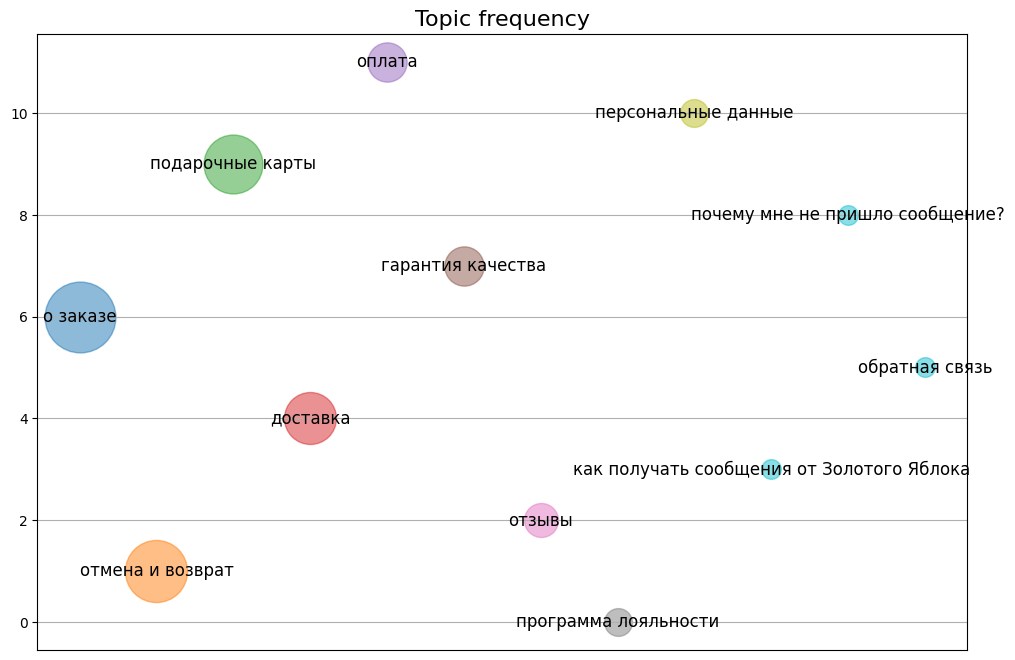

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(documents)

theme_counts = df['theme'].value_counts()

themes = theme_counts.index
frequencies = theme_counts.values

colors = plt.colormaps.get_cmap('tab10')


plt.figure(figsize=(12, 8))

y_positions = np.random.choice(len(themes), len(range(len(themes))), replace=False)

for i, theme in enumerate(themes):
    plt.scatter(theme, y_positions[i], s=frequencies[i] * 200, alpha=0.5, color=colors(i))

for i, theme in enumerate(themes):
    plt.text(theme, y_positions[i], theme, ha='center', va='center', fontsize=12, color='black')

plt.title('Topic frequency', fontsize=16)
plt.grid(True)
plt.xticks([])

plt.show()


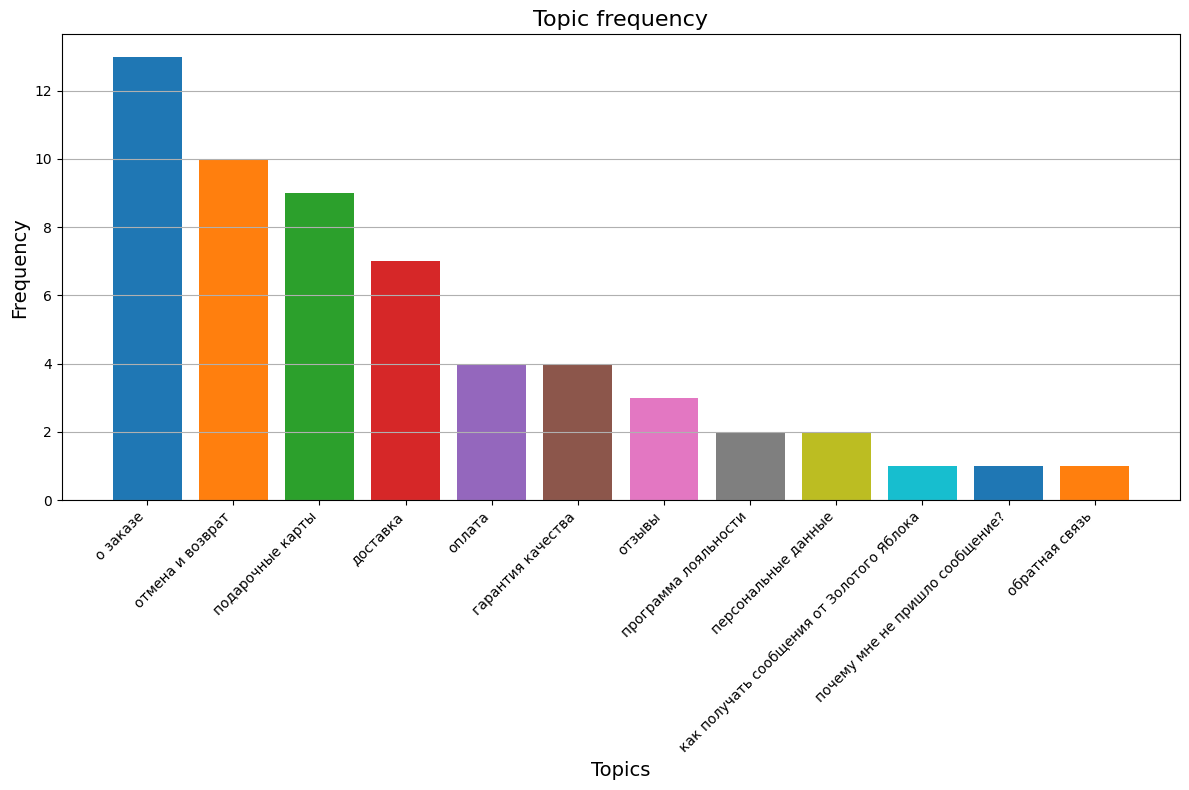

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(documents)

theme_counts = df['theme'].value_counts()

themes = theme_counts.index
frequencies = theme_counts.values

plt.figure(figsize=(12, 8))
plt.bar(themes, frequencies, color=plt.cm.tab10.colors)  

plt.title('Topic frequency', fontsize=16)
plt.xlabel('Topics', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tight_layout() 
plt.show()


## Этап 2: формируем поиск по эмбедингам

In [15]:
!pip install sentence-transformers


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [14]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('BAAI/bge-m3')

batch_size = 16
device = 'cpu'

documents['embeddings'] = embedder.encode(
    documents['text'],
    normalize_embeddings=True,
    device=device,
    batch_size=batch_size,
    show_progress_bar=True
).tolist()
documents.head(3)

/Users/timtibilov/arcadia/junk/timtibilov/.venv/lib/python3.12/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 4/4 [00:16<00:00,  4.14s/it]


,id,text,theme,embeddings
0,0-0,## о заказе: как сделать заказ?\n\nДобавьте ну...,о заказе,"[0.026145432144403458, 0.02190656214952469, -0..."
1,0-1,## о заказе: не удалось оплатить заказ. Что де...,о заказе,"[-0.024513285607099533, 0.033122703433036804, ..."
2,0-2,## о заказе: почему заказ разделился на нескол...,о заказе,"[-0.02694978006184101, -0.016292406246066093, ..."


In [15]:
query = 'сколько баллов на карты?'

query_embedding = embedder.encode(
    query, 
    normalize_embeddings=True,
    device=device,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True
)
query_embedding

Batches: 100%|██████████| 1/1 [00:00<00:00,  6.67it/s]


array([ 0.00814103, -0.01703076, -0.05264129, ..., -0.02193919,
       -0.00238489,  0.0247736 ], dtype=float32)

In [19]:
import numpy as np
from sklearn.neighbors import NearestNeighbors


# Настройка модели KNN
num_neighbors = 3  # Количество ближайших соседей, которые мы хотим найти
knn = NearestNeighbors(n_neighbors=num_neighbors, metric='cosine')

# Обучаем KNN на эмбеддингах документов
knn.fit(documents['embeddings'].tolist())

# Выполняем поиск ближайших соседей для эмбеддинга запроса
distances, indices = knn.kneighbors(query_embedding.reshape(1, -1))

# Выводим результаты
print("Indices of top-3 similar documents:", indices.flatten())
print("Cosine distances to top-3 documents:", distances.flatten())

Indices of top-3 similar documents: [44 42 19]
Cosine distances to top-3 documents: [0.4347621  0.44986318 0.46165597]


In [18]:
rel_docs = documents.iloc[indices.flatten()].text
rel_docs

44    ## программа лояльности: у меня уже есть карта...
42    ## подарочные карты: как узнать баланс карты?\...
19    ## отмена и возврат: когда вернутся бонусы?\n\...
Name: text, dtype: object

## Этап 3: отправляем запрос в YandexGPT

https://yandex.cloud/ru/docs/iam/operations/iam-token/create

https://yandex.cloud/ru/docs/foundation-models/quickstart/yandexgpt

In [ ]:
# with open('.cloud_token') as f:
#    cloud_token = f.read().strip()
cloud_token = 'MY_TOKEN'

In [22]:
response = requests.post('https://iam.api.cloud.yandex.net/iam/v1/tokens', json={'yandexPassportOauthToken': cloud_token}).json()

iam_token = response['iamToken']

In [ ]:
folder_id = 'MY_FOLDER'

prompt = '''Ты сотрудник службы поддержки маркетплейса Золотое Яблоко. 
Тебе на вход подается вопрос пользователя и релевантные документы по вопросу. 
Твоя задача ответить на вопрос пользователя кратко и лаконично, используя знания из предоставленных документов. 
Если ответ на вопрос не содержится в документах, то напиши "Извините, не могу вам помочь."'''

In [26]:
print(prompt)

Ты сотрудник службы поддержки маркетплейса Золотое Яблоко. 
Тебе на вход подается вопрос пользователя и релевантные документы по вопросу. 
Твоя задача ответить на вопрос пользователя кратко и лаконично, используя знания из предоставленных документов. 
Если ответ на вопрос не содержится в документах, то напиши "Извините, не могу вам помочь."


In [27]:
def get_messages(prompt, query, list_of_docs):
    messages = []
    messages.append(dict(role='system', text=prompt))
    messages.append(dict(role='user', text=f'Запрос пользователя:\n{query}'))
    docs = '\n\n'.join(list_of_docs)
    messages.append(dict(role='user', text=f'Найденные релевантные документы по запросу:\n{docs}'))
    return messages

In [28]:
query = 'как узнать сколько баллов на карте летуаль?'
messages = get_messages(prompt, query, rel_docs)
messages

[{'role': 'system',
  'text': 'Ты сотрудник службы поддержки маркетплейса Золотое Яблоко. \nТебе на вход подается вопрос пользователя и релевантные документы по вопросу. \nТвоя задача ответить на вопрос пользователя кратко и лаконично, используя знания из предоставленных документов. \nЕсли ответ на вопрос не содержится в документах, то напиши "Извините, не могу вам помочь."'},
 {'role': 'user',
  'text': 'Запрос пользователя:\nкак узнать сколько баллов на карте летуаль?'},
 {'role': 'user',
  'text': 'Найденные релевантные документы по запросу:\n## программа лояльности: у меня уже есть карта. Как ей воспользоваться?\n\nВойдите в личный кабинет, используя номер телефона, который вы указывали при регистрации карты. Ваша скидка и бонусные баллы действуют в интернет-магазине и офлайн-супермаркетах. *Есть бренды, на которые не действует скидка по программе лояльности. Но с нашим огромным ассортиментом это не страшно. Уверены, вы найдете нужные товары!\n\n## подарочные карты: как узнать бала

In [ ]:
config = {
  'modelUri': f'gpt://{folder_id}/yandexgpt/rc',
  'completionOptions': {
    'stream': False,
    'temperature': 0.6,
    'maxTokens': '2000'
  },
  'messages': messages
}

url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {iam_token}"
}


In [30]:
response = requests.post(url, headers=headers, json=config)
result = response.json()
result

{'result': {'alternatives': [{'message': {'role': 'assistant',
     'text': 'Извините, не могу вам помочь.'},
    'status': 'ALTERNATIVE_STATUS_FINAL'}],
  'usage': {'inputTextTokens': '421',
   'completionTokens': '8',
   'totalTokens': '429',
   'completionTokensDetails': {'reasoningTokens': '0'}},
  'modelVersion': 'yagpt-5.1-2025-08'}}

In [51]:
print(result['result']['alternatives'][0]['message']['text'])

Извините, не могу вам помочь.


## Этап 4: собираем синтетический бенч

In [31]:
bench_prompt = """Задание:
Тебе на вход подается документ из раздела FAQ для маркетплейса Золотое Яблоко. 
Тебе необходимо придумать вопрос, а также написать к нему правильный ответ, 
как будто ты имитируешь общение пользователя с оператором поддержки, который столкнулся с проблемой, решения для которой написано в данном документе.
Не используй заголовок документа как вопрос, придумай свой. Вопрос должен быть лаконичным, но немного непонятным, каверзным, и при этом решаться информацией из заданного документа.
Ответ должен быть кратким и сформулированным по заданному документу.

В вопросе можешь использовать какие-нибудь опечатки (необязательно), или непонятные/нетривиальные формулировки, чтобы не сразу понятно было, что ты как пользователь хочешь от поддержки.

Формат:
Сначала выведи вопрос, затем на следующей строке разделитель '---', затем на следующей строке ответ на вопрос. Не используй никакие другие слова или поясниения - только вопрос и только ответ через разделитель. 

Документ:
"""

In [32]:
def get_data_for_bench(prompt, document):
    messages = []
    messages.append(dict(role='system', text=prompt + document))
    
    config = {
        'modelUri': f'gpt://{folder_id}/yandexgpt/rc',
        'completionOptions': {
            'stream': False,
            'temperature': 0.6,
            'maxTokens': '2000'
        },
        'messages': messages
    }

    response = requests.post(url, headers=headers, json=config)
    result = response.json()
    result

    return result['result']['alternatives'][0]['message']['text']
    

In [33]:
import time
from tqdm import tqdm

benchmark = []

for doc in tqdm(documents.to_dict('records')):
    question, answer = get_data_for_bench(bench_prompt, doc['text']).split('---')
    time.sleep(0.5)
    benchmark.append(dict(question=question.strip(), reference_answer=answer.strip(), rel_document=doc['id']))

100%|██████████| 57/57 [01:21<00:00,  1.44s/it]


In [34]:
benchmark = pd.DataFrame(benchmark)
benchmark.head()

,question,reference_answer,rel_document
0,чё делать то надо чтоб купить у вас че нить?,"Чтобы сделать заказ, добавьте нужные товары в ...",0-0
1,"Почему деньги списались, а заказ не оплатился,...",Если при ошибке оплаты были списаны денежные с...,0-1
2,"А чё за дела, почему мой заказ пришёл в двух п...","Ваш заказ был разделён на несколько посылок, п...",0-2
3,"А чё за дела, я заказал, а в кабинете ничё не ...",Ваш заказ отобразится в личном кабинете в тече...,0-3
4,"А если я уже заказал товар, но вдруг понял, чт...",Изменить способ доставки с курьера на самовыво...,0-4


In [35]:
hit_rate_at_3 = []

for sample in benchmark.to_dict('records'):
    query_embedding = embedder.encode(
        sample['question'], 
        normalize_embeddings=True,
        device=device,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    distances, indices = knn.kneighbors(query_embedding.reshape(1, -1))
    retrieved_ids = set(documents.iloc[indices.flatten()].id)

    hit_rate_at_3.append(int(sample['rel_document'] in retrieved_ids))

np.mean(hit_rate_at_3)

np.float64(0.8947368421052632)

In [36]:
llm_judge_prompt = """Ты являешься сотрудником контроля качества службы поддержки маркетплейса Золотое Яблоко. 
Тебе необходимо ознакомиться с вопросом и документом, в котором есть информация о решении проблемы, а также оценить качество ответа, который оператор дал на заданный вопрос пользователя.
Тебе необходимо поставить оценку от 0 до 2. Значения оценок:
0 - ответ не решает вопрос пользователя, ответ не относится к теме, либо отвечает на другой вопрос, либо частично/полностью не соответствует информации в документе.
1 - ответ может быть полезен пользователю, но отвечает на его вопрос лишь частично, ответ неполный.
2 - ответ полностью отвечает на вопрос пользователя, является полезным и полностью соответствует информации в документе.

При оценке выведи ТОЛЬКО число - оценка ответа на вопрос.
"""

In [37]:
def get_data_for_eval(prompt, model_answer, bench_sample):
    messages = []
    messages.append(dict(role='system', text=f'{prompt}\n\nВопрос:\n{bench_sample["question"]}\n\nРелевантный документ:\n{sample["rel_doc_text"]}\n\nОтвет оператора:\n{model_answer}'))
    
    config = {
        'modelUri': f'gpt://{folder_id}/yandexgpt/rc',
        'completionOptions': {
            'stream': False,
            'temperature': 0.6,
            'maxTokens': '2000'
        },
        'messages': messages
    }

    response = requests.post(url, headers=headers, json=config)
    result = response.json()
    result

    return result['result']['alternatives'][0]['message']['text']
    

In [38]:
def get_messages(prompt, query, list_of_docs):
    messages = []
    messages.append(dict(role='system', text=prompt))
    messages.append(dict(role='user', text=f'Запрос пользователя:\n{query}'))
    docs = '\n\n'.join(list_of_docs)
    messages.append(dict(role='user', text=f'Найденные релевантные документы по запросу:\n{docs}'))
    
    config = {
        'modelUri': f'gpt://{folder_id}/yandexgpt/rc',
        'completionOptions': {
            'stream': False,
            'temperature': 0.6,
            'maxTokens': '2000'
        },
        'messages': messages
    }

    response = requests.post(url, headers=headers, json=config)
    result = response.json()
    result

    return result['result']['alternatives'][0]['message']['text']
    

In [39]:
id_to_text = dict(zip(documents.id, documents.text))
benchmark['rel_doc_text'] = benchmark.rel_document.apply(id_to_text.get)

In [40]:
eval = []

for sample in benchmark.to_dict('records'):
    query_embedding = embedder.encode(
        sample['question'], 
        normalize_embeddings=True,
        device=device,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    distances, indices = knn.kneighbors(query_embedding.reshape(1, -1))
    retrieved_ids = documents.iloc[indices.flatten()].text

    model_answer = get_messages(prompt, sample['question'], retrieved_ids)
    time.sleep(0.5)
    eval.append(get_data_for_eval(llm_judge_prompt, model_answer, sample))

In [ ]:
benchmark.to_excel('benchmark_ga.xlsx')

In [41]:
from collections import Counter

eval = list(map(int, eval))
np.mean(eval), Counter(eval)

(np.float64(1.8596491228070176), Counter({2: 51, 1: 4, 0: 2}))